# SMS Spam Classification with a Neural Network From Scratch
Using only NumPy, Pandas and Matplotlib.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

df = pd.read_csv("spam_cleaned.csv")
df.head()

,label,text
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry in a wkly comp to win fa cup final ...
3,0,u dun say so early hor u c already then say
4,0,nah i dont think he goes to usf he lives aroun...


## Build Vocabulary

In [3]:
vocab={}
for text in df['text']:
    for w in text.split():
        if w not in vocab:
            vocab[w]=len(vocab)

print("Vocabulary:",len(vocab))

Vocabulary: 8531


## Bag of Words

In [4]:
X=np.zeros((len(df),len(vocab)))
for i,text in enumerate(df['text']):
    for w in text.split():
        if w in vocab:
            X[i,vocab[w]]+=1

y=df['label'].values.reshape(-1,1)
print(X.shape,y.shape)

(5166, 8531) (5166, 1)


## Train/Test Split

In [5]:
np.random.seed(42)
idx=np.random.permutation(len(X))
split=int(0.8*len(X))
tr,te=idx[:split],idx[split:]
X_train,X_test=X[tr],X[te]
y_train,y_test=y[tr],y[te]

## Neural Network Initialization

In [6]:
input_size=X_train.shape[1]
hidden_size=64
output_size=1

W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)
b2 = np.zeros((1, output_size))

## Activation Functions

In [7]:
def relu(x):
    return np.maximum(0,x)

def relu_derivative(x):
    return (x>0).astype(float)

def sigmoid(x):
    return 1/(1+np.exp(-x))

## Forward, Loss, Backprop

In [8]:
def forward(X):
    Z1=X@W1+b1
    A1=relu(Z1)
    Z2=A1@W2+b2
    A2=sigmoid(Z2)
    return Z1,A1,Z2,A2

def loss(y,p):
    eps=1e-9
    p=np.clip(p,eps,1-eps)
    return -np.mean(y*np.log(p)+(1-y)*np.log(1-p))

def backward(X,y,Z1,A1,A2):
    global W1,W2,b1,b2
    m=len(X)
    dZ2=A2-y
    dW2=A1.T@dZ2/m
    db2=np.sum(dZ2,axis=0,keepdims=True)/m
    dA1=dZ2@W2.T
    dZ1=dA1*relu_derivative(Z1)
    dW1=X.T@dZ1/m
    db1=np.sum(dZ1,axis=0,keepdims=True)/m
    return dW1,db1,dW2,db2

## Training

In [ ]:
lr=0.01
epochs=200
losses=[]

for epoch in range(epochs):
    Z1,A1,Z2,A2=forward(X_train)
    l=loss(y_train,A2)
    losses.append(l)
    dW1,db1,dW2,db2=backward(X_train,y_train,Z1,A1,A2)
    W1-=lr*dW1
    b1-=lr*db1
    W2-=lr*dW2
    b2-=lr*db2
    if epoch%1000==0:
        print(epoch,l)

0 0.7017361274952696


## Loss Curve

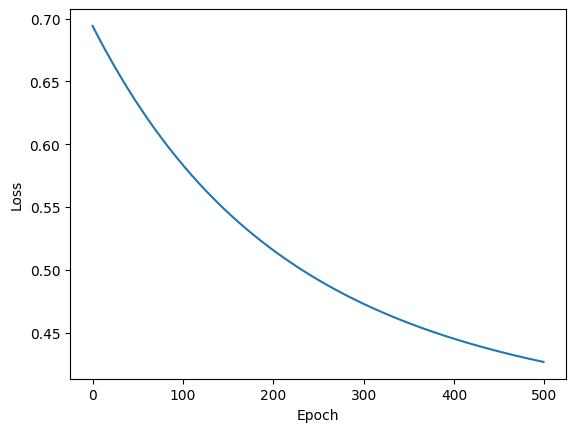

In [ ]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Evaluation

Accuracy: 0.8762088974854932
Precision 0.0
Recall 0.0
F1 0.0


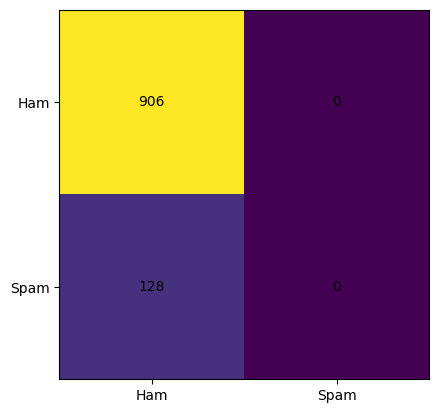

In [ ]:
_,_,_,pred=forward(X_test)
pred=(pred>=0.5).astype(int)
acc=np.mean(pred==y_test)
print("Accuracy:",acc)

TP=np.sum((pred==1)&(y_test==1))
TN=np.sum((pred==0)&(y_test==0))
FP=np.sum((pred==1)&(y_test==0))
FN=np.sum((pred==0)&(y_test==1))

precision=TP/(TP+FP+1e-9)
recall=TP/(TP+FN+1e-9)
f1=2*precision*recall/(precision+recall+1e-9)

print("Precision",precision)
print("Recall",recall)
print("F1",f1)

cm=np.array([[TN,FP],[FN,TP]])
plt.imshow(cm)
for i in range(2):
    for j in range(2):
        plt.text(j,i,str(cm[i,j]),ha='center',va='center')
plt.xticks([0,1],["Ham","Spam"])
plt.yticks([0,1],["Ham","Spam"])
plt.show()

## Predict Custom Message

In [ ]:
def vectorize(msg):
    x=np.zeros((1,len(vocab)))
    for w in msg.lower().split():
        if w in vocab:
            x[0,vocab[w]]+=1
    return x

msg='free entry in a wkly comp to win fa cup final .'
_,_,_,p=forward(vectorize(msg))
print('Spam' if p[0,0]>=0.5 else 'Ham',p[0,0])

NameError: name 'forward' is not defined

In [ ]:
print(df["label"].value_counts())

label
0    4513
1     653
Name: count, dtype: int64


In [ ]:
print(losses[-1:])

[0.09544457909368365]


In [ ]:
np.savez(
    "model.npz",
    W1=W1,
    b1=b1,
    W2=W2,
    b2=b2
)

np.save("vocab.npy", vocab, allow_pickle=True)